<a href="https://colab.research.google.com/github/mhawkes2/AML/blob/main/AML_EOS_Insurance_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Libraries & Datasets

All necessary python libraries are imported here to complete our project.

Also, our two datsets are imported in and turned into dataframes.

In [ ]:
import numpy as np, pandas as pd, sklearn, seaborn as sns, matplotlib.pyplot as plt, xgboost
from scipy import stats

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBClassifier, XGBRegressor
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, average_precision_score, precision_score, recall_score, f1_score, precision_recall_curve, roc_auc_score, balanced_accuracy_score
from sklearn.impute import SimpleImputer
import joblib

sns.set(context='notebook', style='whitegrid')

In [ ]:
driver_test_filepath='/content/safe_driver_test.csv'
driver_train_filepath='/content/safe_driver_train.csv'
claims_test_filepath='/content/claims_severity_test.csv'
claims_train_filepath='/content/claims_severity_train.csv'

driver_test_df=pd.read_csv(driver_test_filepath)
driver_train_df=pd.read_csv(driver_train_filepath)

claims_test_df=pd.read_csv(claims_test_filepath)
claims_train_df=pd.read_csv(claims_train_filepath)

# Building Preprocessors

Function to create column preprocessors for datasets. Will be used later for each dataset's preprocessing.

In [ ]:
def build_preprocessor(numeric_features, categorical_features):
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])

    return ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)
        ]
    )

# Dataset 1: Safe Driver Prediction (Classification)

The Porto Seguro's Safe Driver Prediction dataset that we use to create models that predicts the probability that a driver will initiate an auto insurance claim in the next year.

Each row relates to a case where we predict a binary value (0 or 1) relating to whether they file a clam (1) or do not file a claim (0).

In this dataset, column names are hidden because insurers keep user data anonymous to prevent leaks.

## Exploratory Data Analysis

Our EDA was designed to visualize correlation and statistical signal in our model. Specifically, how a feature affects our target prediction.

Anonymous data made it difficult to visualize meaningful feature between relationships.

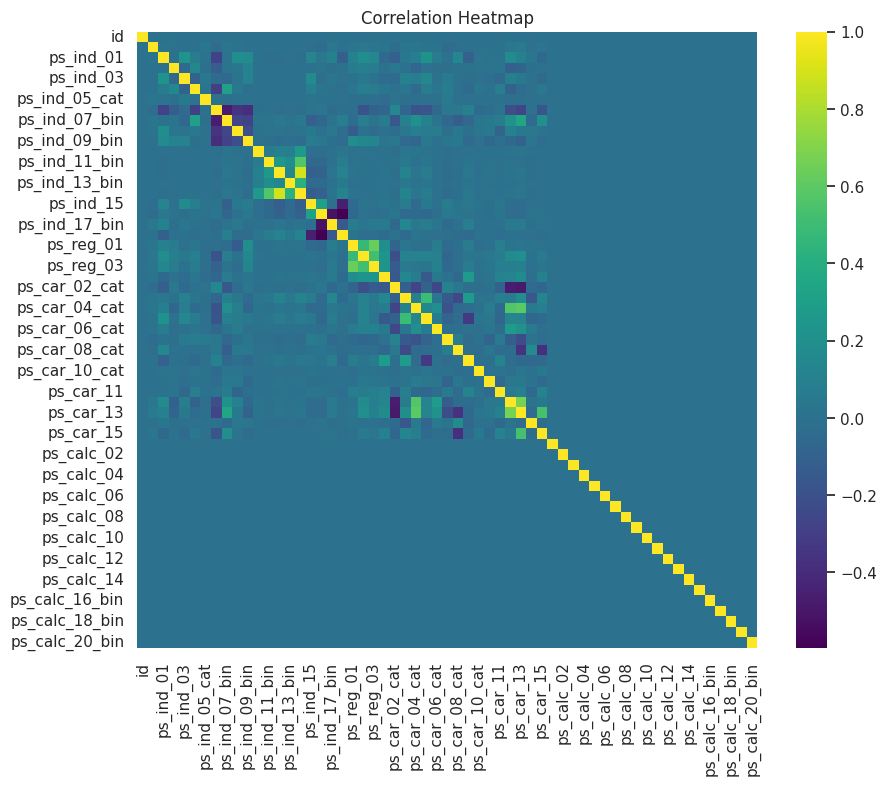

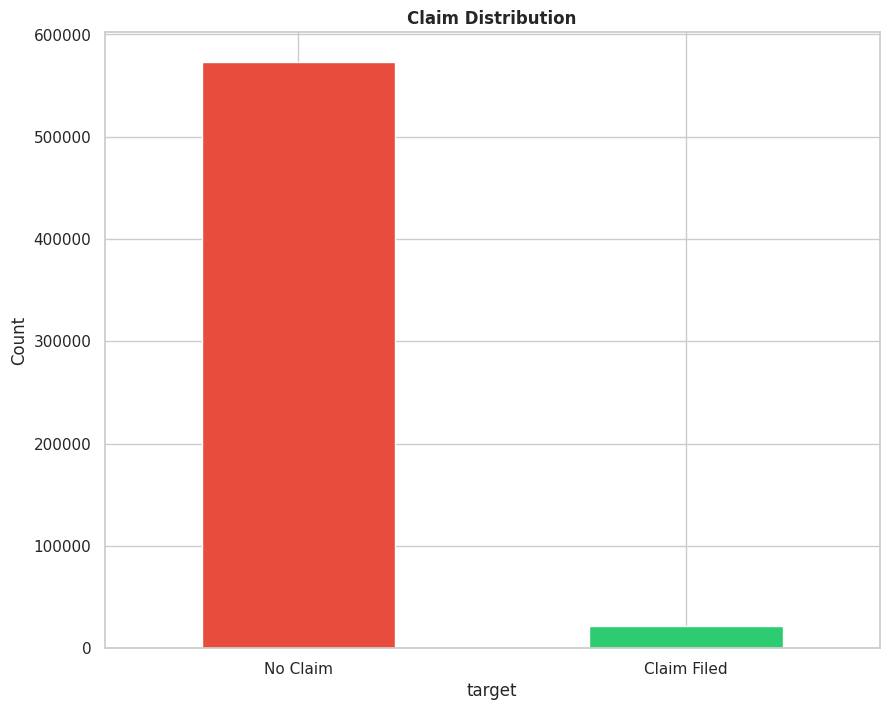

No Claim: 573518 (96.36%)
Claim: 21694 (3.64%)

Top 10 Features by Missing Rate:
id                   0.0000%
target               0.0000%
ps_ind_01            0.0000%
ps_ind_02_cat        0.0000%
ps_ind_03            0.0000%
ps_ind_04_cat        0.0000%
ps_ind_05_cat        0.0000%
ps_ind_06_bin        0.0000%
ps_ind_07_bin        0.0000%
ps_ind_08_bin        0.0000%

Binary columns (17): ['ps_ind_06_bin', 'ps_ind_07_bin', 'ps_ind_08_bin', 'ps_ind_09_bin', 'ps_ind_10_bin', 'ps_ind_11_bin', 'ps_ind_12_bin', 'ps_ind_13_bin', 'ps_ind_16_bin', 'ps_ind_17_bin', 'ps_ind_18_bin', 'ps_calc_15_bin', 'ps_calc_16_bin', 'ps_calc_17_bin', 'ps_calc_18_bin', 'ps_calc_19_bin', 'ps_calc_20_bin']
Categorical columns (14): ['ps_ind_02_cat', 'ps_ind_04_cat', 'ps_ind_05_cat', 'ps_car_01_cat', 'ps_car_02_cat', 'ps_car_03_cat', 'ps_car_04_cat', 'ps_car_05_cat', 'ps_car_06_cat', 'ps_car_07_cat', 'ps_car_08_cat', 'ps_car_09_cat', 'ps_car_10_cat', 'ps_car_11_cat']
Continuous columns (26): ['ps_ind_01', 'ps_ind

In [ ]:
# Correlation matrix
corr = driver_train_df.corr(numeric_only=False)
fig, ax = plt.subplots(figsize=(10,8))
sns.heatmap(corr, annot=False, cmap='viridis')
ax.set_title('Correlation Heatmap')
plt.show()

# Claim distribution
target_counts = driver_train_df['target'].value_counts()
total = target_counts[0] + target_counts[1]

fig, ax = plt.subplots(figsize=(10,8))
target_counts.plot(kind='bar', color=['#e74c3c', '#2ecc71'])
plt.title('Claim Distribution', fontweight='bold')
plt.xticks([0, 1], ['No Claim', 'Claim Filed'], rotation=0)
plt.ylabel('Count')
plt.show()

print(f"No Claim: {target_counts[0]} ({target_counts[0] / total:.2%})")
print(f"Claim: {target_counts[1]} ({target_counts[1] / total:.2%})")

# Missing Values
missing_rate = driver_train_df.isna().mean().sort_values(ascending=False)
top_missing = missing_rate.head(10)

print("\nTop 10 Features by Missing Rate:")
for col, rate in top_missing.items():
    print(f"{col:<20} {rate:.4%}")

# Differentiating Columns
driver_bin_cols = [col for col in driver_train_df.columns if col.endswith("bin")]
driver_cat_cols = [col for col in driver_train_df.columns if col.endswith("cat")]
driver_cont_cols = [
    col for col in driver_train_df.columns
    if col not in driver_bin_cols + driver_cat_cols + ["id"] + ["target"]
]

print(f"\nBinary columns ({len(driver_bin_cols)}):", driver_bin_cols)
print(f"Categorical columns ({len(driver_cat_cols)}):", driver_cat_cols)
print(f"Continuous columns ({len(driver_cont_cols)}):", driver_cont_cols)

In [ ]:
scaler = MinMaxScaler()
driver_train_df[driver_cont_cols] = scaler.fit_transform(driver_train_df[driver_cont_cols])

# Binary features (signed %)
driver_bin_effect = {}
for col in driver_bin_cols:
    rates = driver_train_df.groupby(col)["target"].mean()
    if len(rates) == 2:
        # Save signed difference: 1-level minus 0-level
        driver_bin_effect[col] = rates.iloc[1] - rates.iloc[0]  # keep sign

driver_bin_effect = pd.Series(driver_bin_effect).sort_values(key=abs, ascending=False)  # sort by magnitude

print("\nBinary Features by Signed Claim-Rate Difference (%):")
for col, diff in driver_bin_effect.items():
    print(f"{col:<25} {diff*100:+.2f}%")  # signed percentage

# Categorical features (signed % per category)
driver_cat_effect = {}
driver_cat_weights = {}  # store per-category signed effect for RiskSum

for col in driver_cat_cols:
    # Compute claim rate per category
    rates = driver_train_df.groupby(col, observed=True)["target"].mean()

    # Signed difference relative to overall mean claim rate
    overall_mean = driver_train_df["target"].mean()
    signed_diff = rates - overall_mean

    # Save the largest absolute difference as the "feature effect"
    driver_cat_effect[col] = signed_diff.abs().max()  # for sorting

    # Save per-category weights for RiskSum
    driver_cat_weights[col] = signed_diff.to_dict()

# Convert to Series and sort by magnitude
driver_cat_effect = pd.Series(driver_cat_effect).sort_values(ascending=False)

print("\nCategorical Features by Signed Claim-Rate Difference (%):")
for col, diff in driver_cat_effect.items():
    print(f"{col:<25} {diff*100:+.2f}%")

# Continuous features (binned, signed %)
driver_cont_effect = {}
for col in driver_cont_cols:
    # Bin continuous values into quartiles
    driver_train_df[f"{col}_bin"] = pd.qcut(driver_train_df[col].fillna(-999), 4, duplicates='drop')
    rates = driver_train_df.groupby(f"{col}_bin", observed=True)["target"].mean()
    # Difference from lowest bin
    driver_cont_effect[col] = (rates - rates.min()).max()
    driver_train_df.drop(columns=f"{col}_bin", inplace=True)

driver_cont_effect = pd.Series(driver_cont_effect).sort_values(key=abs, ascending=False)

print("\nContinuous Features by Signed Claim-Rate Difference (binned, %):")
for col, diff in driver_cont_effect.items():
    print(f"{col:<25} {diff*100:+.2f}%")


Binary Features by Signed Claim-Rate Difference (%):
ps_ind_17_bin             +2.13%
ps_ind_10_bin             +1.76%
ps_ind_12_bin             +1.51%
ps_ind_13_bin             +1.50%
ps_ind_07_bin             +1.47%
ps_ind_06_bin             -1.30%
ps_ind_16_bin             -1.10%
ps_ind_11_bin             +0.92%
ps_ind_08_bin             +0.67%
ps_ind_09_bin             -0.40%
ps_ind_18_bin             +0.24%
ps_calc_19_bin            -0.07%
ps_calc_20_bin            -0.06%
ps_calc_15_bin            -0.03%
ps_calc_16_bin            +0.02%
ps_calc_18_bin            +0.02%
ps_calc_17_bin            -0.01%

Categorical Features by Signed Claim-Rate Difference (%):
ps_ind_04_cat             +36.11%
ps_car_01_cat             +28.13%
ps_ind_02_cat             +14.87%
ps_car_04_cat             +5.71%
ps_car_09_cat             +5.49%
ps_ind_05_cat             +4.69%
ps_car_07_cat             +4.17%
ps_car_11_cat             +3.87%
ps_car_02_cat             +3.64%
ps_car_06_cat             

## Feature Engineering

Our main features we engineered were RiskSum, a weighted sum of each feature based on its presence and effect on the target prediction.

After this we made binary RiskFlags for our model to used, activated based on if a certain RiskSum threshold is reached.

In [ ]:
# Initialize RiskSum columns
driver_train_df['RiskSum_bin'] = 0
driver_train_df['RiskSum_cat'] = 0
driver_train_df['RiskSum_cont'] = 0

# Binary RiskSum
for col in driver_bin_cols:
    driver_train_df['RiskSum_bin'] += driver_train_df[col] * driver_bin_effect[col]

# Categorical RiskSum
for col in driver_cat_cols:
    driver_train_df['RiskSum_cat'] += driver_train_df[col].map(driver_cat_weights[col])

# Continuous RiskSum
for col in driver_cont_cols:
    driver_train_df['RiskSum_cont'] += driver_train_df[col] * driver_cont_effect[col]

# Total RiskSum
driver_train_df['RiskSum_total'] = (
    driver_train_df['RiskSum_bin'] +
    driver_train_df['RiskSum_cat'] +
    driver_train_df['RiskSum_cont']
)

# Average RiskSum_total by target
avg_risk_by_target = driver_train_df.groupby("target")["RiskSum_total"].mean()

print("\nAverage RiskSum_total by Target:")
for target_value, avg_risk in avg_risk_by_target.items():
    print(f"Target {target_value}: {avg_risk:.4f}")

threshold = (0.0640 + 0.0860) / 2  # 0.075 as midpoint
driver_train_df['RiskFlag'] = (driver_train_df['RiskSum_total'] > threshold).astype(int)
driver_train_df['HighRiskFlag'] = (driver_train_df['RiskSum_total'] > 0.0860).astype(int)


Average RiskSum_total by Target:
Target 0: 0.0619
Target 1: 0.0841


## Preprocessing

Prepare our dataset for model creation.

In [ ]:
# Drop columns we don't want to model on right now
cols_to_drop = ['id']

X = driver_train_df.drop(columns=['target','id'], axis=1)  # Adjust column name if different
y = driver_train_df['target']

driver_preprocessor = build_preprocessor(driver_bin_cols+driver_cat_cols+driver_cont_cols, [])

## Determining the Best Model

Tested 4 models (Logistic Regression, KNN, Random Forest, XGBoost) to see what model works the best for this problem.

Training set size: 476169
Validation set size: 119043
Training class distribution:
target
0    0.963553
1    0.036447
Name: proportion, dtype: float64


=== Logistic ===
[[71993 42711]
 [ 1968  2371]]
              precision    recall  f1-score   support

    No Claim       0.97      0.63      0.76    114704
       Claim       0.05      0.55      0.10      4339

    accuracy                           0.62    119043
   macro avg       0.51      0.59      0.43    119043
weighted avg       0.94      0.62      0.74    119043


=== KNN ===
[[114635     69]
 [  4332      7]]
              precision    recall  f1-score   support

    No Claim       0.96      1.00      0.98    114704
       Claim       0.09      0.00      0.00      4339

    accuracy                           0.96    119043
   macro avg       0.53      0.50      0.49    119043
weighted avg       0.93      0.96      0.95    119043


=== RandomForest ===
[[114704      0]
 [  4339      0]]
              precision    recall  f1-sc

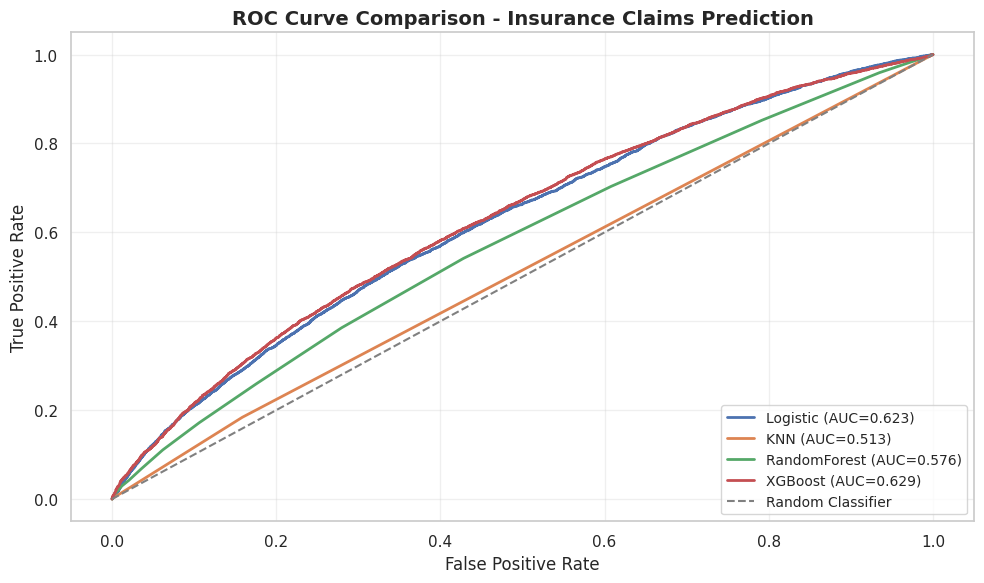

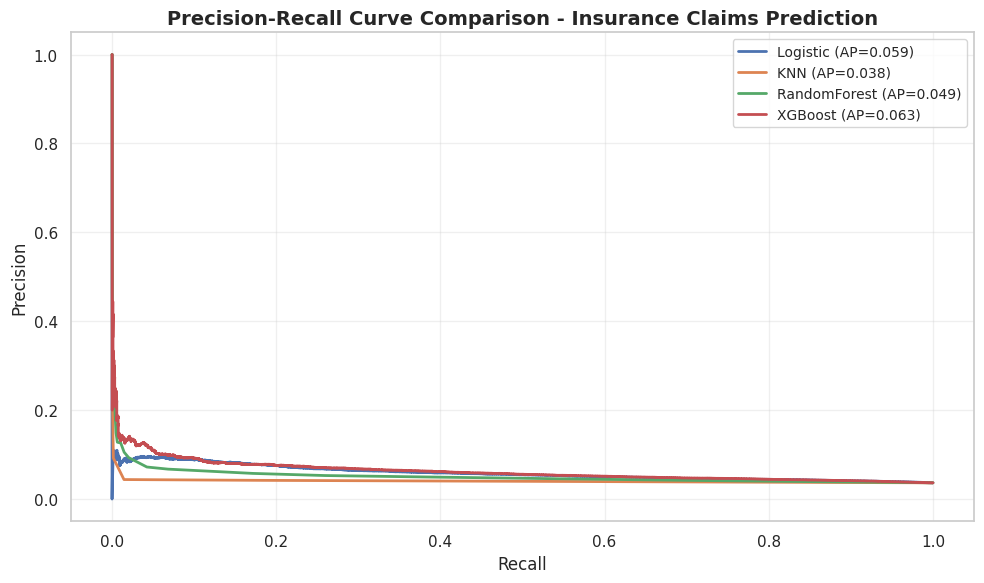


SUMMARY TABLE - MODEL PERFORMANCE
       Model  Precision  Recall  F1-Score  ROC-AUC  Avg Precision  Balanced Accuracy
    Logistic     0.0526  0.5464    0.0960   0.6233         0.0588             0.5870
         KNN     0.0921  0.0016    0.0032   0.5127         0.0377             0.5005
RandomForest     0.0000  0.0000    0.0000   0.5755         0.0487             0.5000
     XGBoost     0.0556  0.5024    0.1001   0.6293         0.0631             0.5898

Note: For imbalanced data (96.36% no claim), focus on:
  - ROC-AUC and Avg Precision (PR-AUC) for overall performance
  - Recall to catch actual claims (minority class)
  - Balanced Accuracy to account for class imbalance


,Model,Precision,Recall,F1-Score,ROC-AUC,Avg Precision,Balanced Accuracy
0,Logistic,0.0526,0.5464,0.0960,0.6233,0.0588,0.5870
1,KNN,0.0921,0.0016,0.0032,0.5127,0.0377,0.5005
2,RandomForest,0.0000,0.0000,0.0000,0.5755,0.0487,0.5000
3,XGBoost,0.0556,0.5024,0.1001,0.6293,0.0631,0.5898


In [ ]:
# Pipelines for each model
pipelines = {
    'Logistic': Pipeline([
        ('prep', driver_preprocessor),
        ('model', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
    ]),
    'KNN': Pipeline([
        ('prep', driver_preprocessor),
        ('model', KNeighborsClassifier(n_neighbors=5))
    ]),
    'RandomForest': Pipeline([
        ('prep', driver_preprocessor),
        ('model', RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced', n_jobs=-1))
    ]),
    'XGBoost': Pipeline([
        ('prep', driver_preprocessor),
        ('model', XGBClassifier(
            random_state=42,
            n_estimators=100,
            learning_rate=0.1,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=26.4,  # 573518/21694 for class imbalance
            objective='binary:logistic',
            tree_method='hist',
            n_jobs=-1,
            eval_metric='logloss'
        ))
    ])
}

driver_X_train, driver_X_val, driver_y_train, driver_y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {len(driver_X_train)}")
print(f"Validation set size: {len(driver_X_val)}")
print(f"Training class distribution:\n{driver_y_train.value_counts(normalize=True)}\n")

# Evaluate each model
results = []
for name, pipe in pipelines.items():
    pipe.fit(driver_X_train, driver_y_train)
    y_pred = pipe.predict(driver_X_val)
    y_prob = pipe.predict_proba(driver_X_val)[:, 1]

    # Calculate metrics (appropriate for imbalanced data)
    prec = precision_score(driver_y_val, y_pred, zero_division=0)
    rec = recall_score(driver_y_val, y_pred)
    f1 = f1_score(driver_y_val, y_pred)
    roc_auc = roc_auc_score(driver_y_val, y_prob)
    avg_prec = average_precision_score(driver_y_val, y_prob)
    bal_acc = balanced_accuracy_score(driver_y_val, y_pred)

    results.append([name, prec, rec, f1, roc_auc, avg_prec, bal_acc])

    print(f"\n{'='*60}")
    print(f"=== {name} ===")
    print(f"{'='*60}")
    print(confusion_matrix(driver_y_val, y_pred))
    print(classification_report(driver_y_val, y_pred, target_names=["No Claim", "Claim"], zero_division=0))

# ROC curve comparison
plt.figure(figsize=(10, 6))
for name, pipe in pipelines.items():
    y_prob = pipe.predict_proba(driver_X_val)[:, 1]
    fpr, tpr, _ = roc_curve(driver_y_val, y_prob)
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={auc(fpr, tpr):.3f})")

plt.plot([0, 1], [0, 1], '--', color='gray', label='Random Classifier')
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve Comparison - Insurance Claims Prediction", fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Precision-Recall curve comparison (better for imbalanced data)
plt.figure(figsize=(10, 6))
for name, pipe in pipelines.items():
    y_prob = pipe.predict_proba(driver_X_val)[:, 1]
    from sklearn.metrics import precision_recall_curve
    precision, recall, _ = precision_recall_curve(driver_y_val, y_prob)
    avg_prec = average_precision_score(driver_y_val, y_prob)
    plt.plot(recall, precision, linewidth=2, label=f"{name} (AP={avg_prec:.3f})")

plt.xlabel("Recall", fontsize=12)
plt.ylabel("Precision", fontsize=12)
plt.title("Precision-Recall Curve Comparison - Insurance Claims Prediction", fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Summary table
df_results = pd.DataFrame(results, columns=[
    "Model", "Precision", "Recall", "F1-Score", "ROC-AUC", "Avg Precision", "Balanced Accuracy"
])
df_results = df_results.round(4)

print(f"\n{'='*80}")
print("SUMMARY TABLE - MODEL PERFORMANCE")
print(f"{'='*80}")
print(df_results.to_string(index=False))
print(f"\n{'='*80}")
print("Note: For imbalanced data (96.36% no claim), focus on:")
print("  - ROC-AUC and Avg Precision (PR-AUC) for overall performance")
print("  - Recall to catch actual claims (minority class)")
print("  - Balanced Accuracy to account for class imbalance")
print(f"{'='*80}")

df_results

## Hyperparameter Tuning & Prediction

Tuned our best model, XGBoost, for this problem and made our final predictions.

In [ ]:
RANDOM_STATE = 42

# XGBoost model
xgb = XGBClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Wrap XGB with preprocessing so it works on the raw Titanic data
xgb_pipe = Pipeline([
    ('prep', driver_preprocessor),   # ColumnTransformer from before
    ('model', xgb)
])

# Hyperparameter search space
param_dist = {
    'model__n_estimators': [200, 400, 600, 800],
    'model__max_depth': [3, 5, 7, 9],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__subsample': [0.6, 0.8, 1.0],
    'model__colsample_bytree': [0.6, 0.8, 1.0],
    'model__min_child_weight': [1, 3, 5]
}

# Cross-validation
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)

# RandomizedSearchCV
rand_search = RandomizedSearchCV(
    estimator=xgb_pipe,
    param_distributions=param_dist,
    n_iter=20,
    scoring='average_precision',
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

# Fit model
rand_search.fit(driver_X_train, driver_y_train)

# Results
print("Best parameters:", rand_search.best_params_)
print("Best CV Accuracy:", rand_search.best_score_)

# Retrain best XGB on all data
best_model = rand_search.best_estimator_
best_model.fit(driver_train_df_model, y_driver_train)

# Predict
kaggle_preds = best_model.predict(driver_test_df_model)

# Create submission file
submission = pd.DataFrame({
    'id': driver_test_df['id'].values,
    'target': kaggle_preds
})
submission.to_csv('driver_submission.csv', index=False)
submission.head()

Fitting 3 folds for each of 20 candidates, totalling 60 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [19:28:06] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best parameters: {'model__subsample': 0.8, 'model__n_estimators': 400, 'model__min_child_weight': 3, 'model__max_depth': 5, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.8}
Best CV Accuracy: 0.0657340877957172


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [19:28:41] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,id,target
0,0,0
1,1,0
2,2,0
3,3,0
4,4,0


# Dataset 2: Claim Severity Prediction (Regression)

The AllState Claims Severity dataset that we use to create models that predicts the loss that an insurance claim will cause for a company.

Each row relates to a case where we predict a continuous value for the claim's loss.

In this dataset, column names are hidden because insurers keep user data anonymous to prevent leaks.

## Exploratory Data Analysis

Our EDA was designed to visualize correlation and statistical signal in our model. Specifically, how a feature affects the predicted loss.

Anonymous data made it difficult to visualize meaningful feature between relationships.

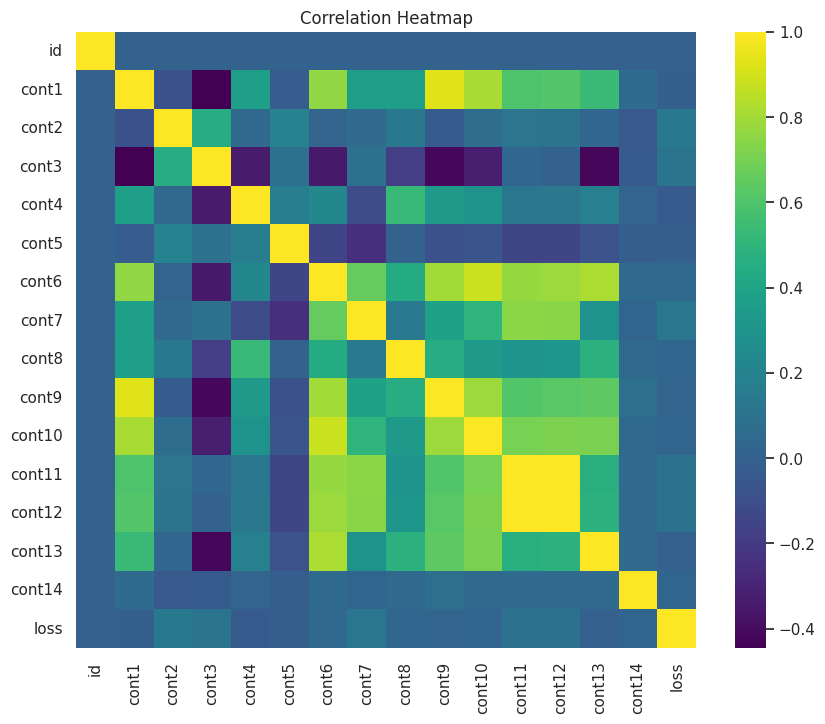

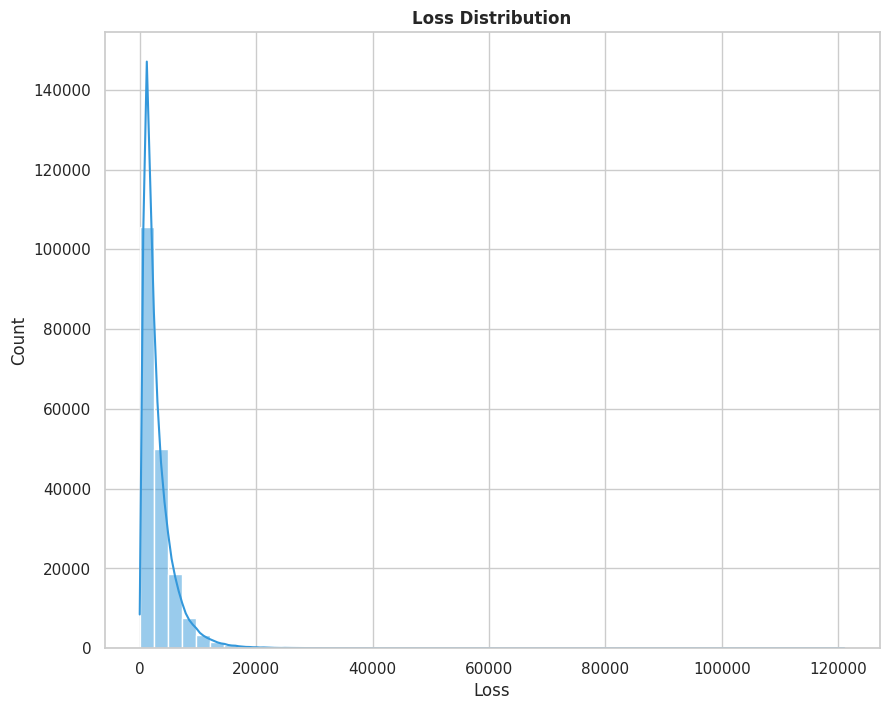

Loss summary:
count    188318.000000
mean       3037.337686
std        2904.086186
min           0.670000
25%        1204.460000
50%        2115.570000
75%        3864.045000
max      121012.250000
Name: loss, dtype: float64

Top 10 Features by Missing Rate:
id                   0.0000%
cat1                 0.0000%
cat2                 0.0000%
cat3                 0.0000%
cat4                 0.0000%
cat5                 0.0000%
cat6                 0.0000%
cat7                 0.0000%
cat8                 0.0000%
cat9                 0.0000%
Categorical columns (116): ['cat1', 'cat2', 'cat3', 'cat4', 'cat5', 'cat6', 'cat7', 'cat8', 'cat9', 'cat10', 'cat11', 'cat12', 'cat13', 'cat14', 'cat15', 'cat16', 'cat17', 'cat18', 'cat19', 'cat20', 'cat21', 'cat22', 'cat23', 'cat24', 'cat25', 'cat26', 'cat27', 'cat28', 'cat29', 'cat30', 'cat31', 'cat32', 'cat33', 'cat34', 'cat35', 'cat36', 'cat37', 'cat38', 'cat39', 'cat40', 'cat41', 'cat42', 'cat43', 'cat44', 'cat45', 'cat46', 'cat47', 'cat48', 

In [ ]:
# Correlation matrix
corr = claims_train_df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(10,8))
sns.heatmap(corr, annot=False, cmap='viridis')
ax.set_title('Correlation Heatmap')
plt.show()

# Claim distribution (now loss distribution)
fig, ax = plt.subplots(figsize=(10,8))
sns.histplot(claims_train_df['loss'], bins=50, kde=True, color='#3498db')
plt.title('Loss Distribution', fontweight='bold')
plt.xlabel('Loss')
plt.ylabel('Count')
plt.show()

print(f"Loss summary:\n{claims_train_df['loss'].describe()}")

# Missing Values
missing_rate = claims_train_df.isna().mean().sort_values(ascending=False)
top_missing = missing_rate.head(10)

print("\nTop 10 Features by Missing Rate:")
for col, rate in top_missing.items():
    print(f"{col:<20} {rate:.4%}")

# Differentiating Columns
claims_cat_cols = [col for col in claims_train_df.columns if "cat" in col]
claims_cont_cols = [
    col for col in claims_train_df.columns
    if col not in claims_cat_cols + ['loss'] + ['id']
]

print(f"Categorical columns ({len(claims_cat_cols)}):", claims_cat_cols)
print(f"Continuous columns ({len(claims_cont_cols)}):", claims_cont_cols)

In [ ]:
# Scale continuous features 0-1
scaler = MinMaxScaler()
claims_train_df[claims_cont_cols] = scaler.fit_transform(claims_train_df[claims_cont_cols])

# Categorical features (signed difference per category)
claims_cat_effect = {}
claims_cat_weights = {}  # store per-category signed effect for RiskSum

overall_mean_loss = claims_train_df["loss"].mean()

for col in claims_cat_cols:
    # Compute mean loss per category
    means = claims_train_df.groupby(col, observed=True)["loss"].mean()

    # Signed difference relative to overall mean loss
    signed_diff = means - overall_mean_loss

    # Save the largest absolute difference as the "feature effect" for ordering
    claims_cat_effect[col] = signed_diff.abs().max()

    # Save per-category weights for RiskSum (normalized)
    claims_cat_weights[col] = (signed_diff / signed_diff.abs().max()).to_dict()  # -1 → +1

# Sort categorical features by magnitude
claims_cat_effect = pd.Series(claims_cat_effect).sort_values(ascending=False)

print("\nCategorical Features by Signed Mean Loss Difference:")
for col, diff in claims_cat_effect.items():
    print(f"{col:<25} {diff:.2f}")

# Continuous features (binned, signed)
claims_cont_effect = {}
for col in claims_cont_cols:
    # Bin continuous values into quartiles
    claims_train_df[f"{col}_bin"] = pd.qcut(claims_train_df[col].fillna(-999), 4, duplicates='drop')
    # Compute mean loss per bin
    means = claims_train_df.groupby(f"{col}_bin", observed=True)["loss"].mean()
    # Difference from lowest bin
    claims_cont_effect[col] = (means - means.min()).max()
    claims_train_df.drop(columns=f"{col}_bin", inplace=True)

claims_cont_effect = pd.Series(claims_cont_effect).sort_values(key=abs, ascending=False)

print("\nContinuous Features by Mean Loss Difference (binned):")
for col, diff in claims_cont_effect.items():
    print(f"{col:<25} {diff:.2f}")


Categorical Features by Signed Mean Loss Difference:
cat116                    64500.39
cat105                    48345.70
cat113                    33626.79
cat115                    26126.58
cat107                    16808.56
cat89                     15609.03
cat102                    15609.03
cat101                    12935.15
cat57                     7202.63
cat90                     6776.70
cat111                    6550.60
cat114                    5821.66
cat7                      5157.74
cat103                    4239.24
cat110                    3983.34
cat64                     3964.67
cat92                     3746.89
cat106                    3733.90
cat79                     3274.49
cat87                     3097.01
cat59                     3096.75
cat58                     3027.62
cat78                     3009.35
cat85                     3000.79
cat16                     2940.65
cat20                     2762.47
cat62                     2747.62
cat17               

## Feature Engineering

Our main features we engineered were RiskSum, a weighted sum of each feature based on its presence and its effect on the loss prediction.

The effect is determined by the loss that is added to the loss prediction by a feature on average.

After this we made a categorical feature that separates each row into 4 quartiles of loss.

In [ ]:
# Compute RiskSum for each row
claims_train_df['RiskSum_cat'] = 0
claims_train_df['RiskSum_cont'] = 0

# Categorical RiskSum
for col in claims_cat_cols:
    claims_train_df['RiskSum_cat'] += claims_train_df[col].map(claims_cat_weights[col])

# Continuous RiskSum (already scaled 0-1)
for col in claims_cont_cols:
    claims_train_df['RiskSum_cont'] += claims_train_df[col] * claims_cont_effect[col]

# Total RiskSum
claims_train_df['RiskSum_total'] = claims_train_df['RiskSum_cat'] + claims_train_df['RiskSum_cont']

# Inspect RiskSum by Loss Quartile
claims_train_df['LossQuartile'] = pd.qcut(claims_train_df['loss'], 4, labels=False)
avg_risk_by_quartile = claims_train_df.groupby("LossQuartile")["RiskSum_total"].mean()

print("\nAverage RiskSum_total by Loss Quartile:")
for quartile, avg_risk in avg_risk_by_quartile.items():
    print(f"Quartile {quartile}: {avg_risk:.4f}")


Average RiskSum_total by Loss Quartile:
Quartile 0: 2886.9199
Quartile 1: 2923.4520
Quartile 2: 2929.2334
Quartile 3: 3064.6299


## Preprocessing

Prepare our dataset for model creation.

In [ ]:
# Drop columns we don't want to model on right now
cols_to_drop = ['id']

X = claims_train_df.drop(columns=['loss','id'], axis=1)  # Adjust column name if different
y = claims_train_df['loss']

claims_preprocessor = build_preprocessor(claims_cont_cols, claims_cat_cols)

## Determining the Best Model

Tested 4 models (Linear Regression, Ridge, Random Forest, XGBoost) to see what model works the best for this problem.

In [ ]:
pipelines = {
    'Linear Regression': Pipeline([
        ('prep', claims_preprocessor),
        ('model', LinearRegression())
    ]),
    'Ridge': Pipeline([
        ('prep', claims_preprocessor),
        ('model', Ridge(alpha=1.0, random_state=42))
    ]),
    'RandomForest': Pipeline([
        ('prep', claims_preprocessor),
        ('model', RandomForestRegressor(random_state=42, n_estimators=100, n_jobs=-1))
    ]),
    'XGBoost': Pipeline([
        ('prep', claims_preprocessor),
        ('model', XGBRegressor(
            random_state=42,
            n_estimators=100,
            learning_rate=0.1,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            tree_method='hist',
            n_jobs=-1
        ))
    ])
}

claims_X_train, claims_X_val, claims_y_train, claims_y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {len(claims_X_train)}")
print(f"Validation set size: {len(claims_X_val)}")
print(f"\nTarget variable (loss) statistics:")
print(f"  Mean: ${claims_y_train.mean():,.2f}")
print(f"  Median: ${claims_y_train.median():,.2f}")
print(f"  Std: ${claims_y_train.std():,.2f}")
print(f"  Min: ${claims_y_train.min():,.2f}")
print(f"  Max: ${claims_y_train.max():,.2f}\n")

# Evaluate each model
results = []

for name, pipe in pipelines.items():
    pipe.fit(claims_X_train, claims_y_train)

    y_pred = pipe.predict(claims_X_val)

    rmse = mean_squared_error(claims_y_val, y_pred)
    mae  = mean_absolute_error(claims_y_val, y_pred)
    r2   = r2_score(claims_y_val, y_pred)

    results.append([name, rmse, mae, r2])

    print(f"\n=== {name} ===")
    print(f"RMSE: {rmse:,.2f}")
    print(f"MAE : {mae:,.2f}")
    print(f"R²  : {r2:.4f}")

Training set size: 150654
Validation set size: 37664

Target variable (loss) statistics:
  Mean: $3,039.63
  Median: $2,115.89
  Std: $2,915.86
  Min: $0.67
  Max: $121,012.25


=== Linear Regression ===
RMSE: 4,066,668.45
MAE : 1,291.43
R²  : 0.5016

=== Ridge ===
RMSE: 4,012,220.50
MAE : 1,290.54
R²  : 0.5083


KeyboardInterrupt: 

## Hyperparameter Tuning & Prediction

Tuned our best model, XGBoost, for this problem and made our final predictions.

In [ ]:
RANDOM_STATE = 42

# XGBoost model
xgb = XGBRegressor(
    random_state=RANDOM_STATE,
    n_jobs=-1,
    objective='reg:squarederror'
)

# Wrap XGB with preprocessing so it works on the raw data
xgb_pipe = Pipeline([
    ('prep', claims_preprocessor),   # ColumnTransformer from before
    ('model', xgb)
])

# Hyperparameter search space
param_dist = {
    'model__n_estimators': [200, 400, 600, 800],
    'model__max_depth': [3, 5, 7, 9],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__subsample': [0.6, 0.8, 1.0],
    'model__colsample_bytree': [0.6, 0.8, 1.0],
    'model__min_child_weight': [1, 3, 5]
}

# Cross-validation
cv = KFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)

# RandomizedSearchCV
rand_search = RandomizedSearchCV(
    estimator=xgb_pipe,
    param_distributions=param_dist,
    n_iter=20,
    scoring='neg_root_mean_squared_error',
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

# Fit model
rand_search.fit(claims_X_train, claims_y_train)

# Results
print("Best parameters:", rand_search.best_params_)
print("Best CV RMSE:", -rand_search.best_score_)

# Retrain best XGB on all data
best_model = rand_search.best_estimator_
best_model.fit(claims_train_df_model, y_claims_train)

# Predict
kaggle_preds = best_model.predict(claims_test_df_model)

# Create submission file
submission = pd.DataFrame({
    'id': claims_test_df['id'].values,
    'loss': kaggle_preds
})
submission.to_csv('claims_submission.csv', index=False)
submission.head()